<div class="alert alert-block alert-success">


# **01 — Understanding the Data**

## **Dataset**
European football data sourced from [Quera's problemset](https://quera.org/problemset/237892).
 
covering competitions, clubs, players, games, appearances, and in-game events.

## **Goal of this notebook**
Before any analysis, we need to know what we're working with:
- how tables are connected? 
- What does each table contain?
- What are the column types, distributions, and missing values?
- Are there any data quality issues worth flagging for cleaning?

## **Questions to answer and tasks to do in later notebooks**
- cleaning/transforming the flagged issues
- feature engineering for richer analysis 
- correlation and relationship analysis to flag for statistical analysis
- statistical testing and hypothesis testing
- kpi design and analysis
- root cause analysis
- final non-technical report of the eda

In [1]:
# importing the necessaries
import sys
import os
# Adding the root to the path to use utils folder
sys.path.append(os.path.abspath(os.path.join('..')))

from utils.db_utils import run_query 
from utils.custom_plots import distribution_plot, outlier_plot, schema_diagram


import plotly.io as pio
pio.renderers.default = "png"  # drop these 2 lines if you want interactive charts locally

<div class="alert alert-block alert-success">

# **First lets take a look at how tables are connected in this database** 

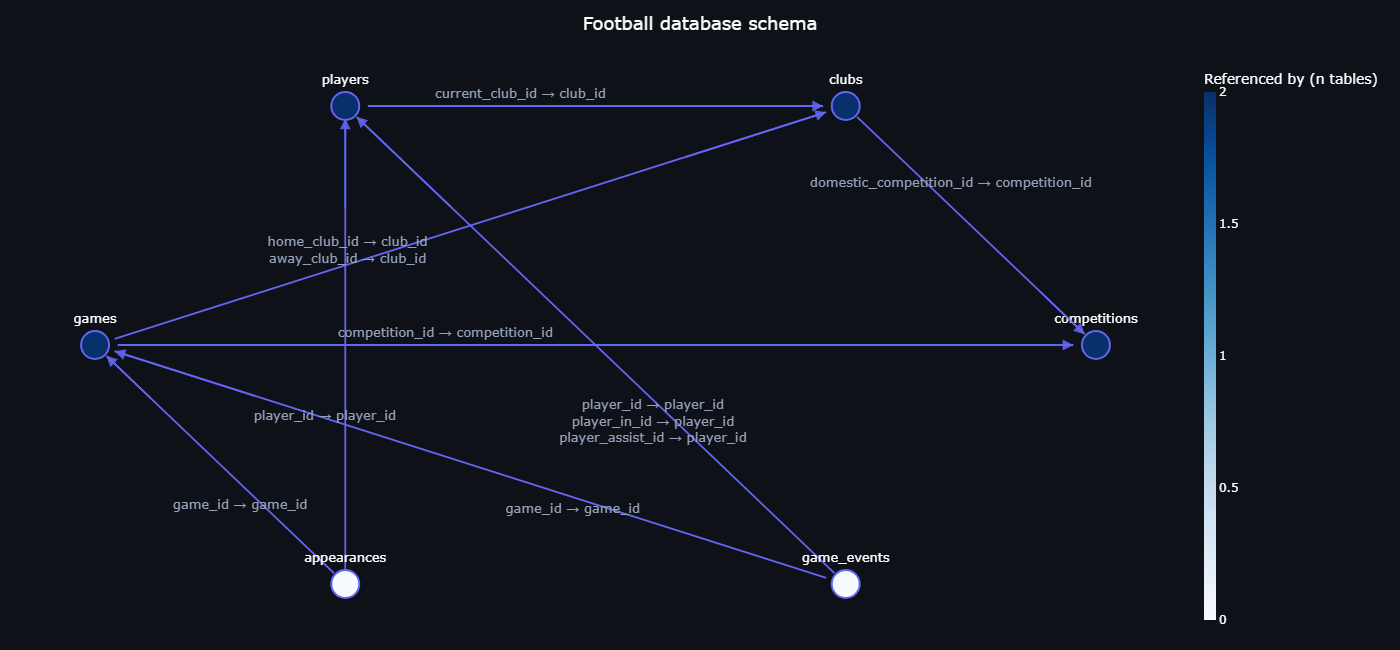

In [3]:
database_diagram=schema_diagram(run_query_fn=run_query,
                                layout='circular',
                                edge_labels='always',
                                title='Football database schema',
                                edge_label_font_size=13)

database_diagram

<div class="alert alert-block alert-success">

#### **we have 6 tables in this database that are connected with different foreign keys**
- as we can see in the plot the only independent table in the database is 'Competitions' 
- all tables other then 'Competitions' are dependent to at least 1 table 
- tables 'appearances' and 'game_events' are referenced by 0 tables 

<div class="alert alert-block alert-success">


# **Now lets look at each table in more depth** 

**1-what is their purpose and what are they features(columns)?**

**2-how many null or missing values they have?**

**3-what is their distribution?**

**4-how their outliers are layedout?**

**5-what are the cleaning opportunities?**

<div class="alert alert-block alert-success">

## **Table: Competition**

In [3]:
competitions_summary = run_query('select * from competitions')

competitions_summary.head(10)

,competition_id,name,type,country_name
0,CIT,italy-cup,domestic_cup,Italy
1,NLSC,johan-cruijff-schaal,other,Netherlands
2,GRP,kypello-elladas,domestic_cup,Greece
3,POSU,supertaca-candido-de-oliveira,other,Portugal
4,RUSS,russian-super-cup,other,Russia
5,SUC,supercopa,other,Spain
6,DK1,superligaen,domestic_league,Denmark
7,ES1,laliga,domestic_league,Spain
8,FR1,ligue-1,domestic_league,France
9,IT1,serie-a,domestic_league,Italy


In [4]:
competitions_summary.describe()

,competition_id,name,type,country_name
count,43,43,43,36
unique,43,43,4,14
top,CIT,italy-cup,domestic_league,England
freq,1,1,14,4


In [5]:
competitions_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   competition_id  43 non-null     str  
 1   name            43 non-null     str  
 2   type            43 non-null     str  
 3   country_name    36 non-null     str  
dtypes: str(4)
memory usage: 3.0 KB


In [6]:
# finding nulls :
competitions_summary[competitions_summary.isnull().any(axis=1)]


,competition_id,name,type,country_name
36,USC,uefa-super-cup,other,NaN
37,EL,europa-league,international_cup,NaN
38,ELQ,europa-league-qualifikation,international_cup,NaN
39,ECLQ,uefa-europa-conference-league-qualifikation,international_cup,NaN
40,CL,uefa-champions-league,international_cup,NaN
41,KLUB,fifa-klub-wm,other,NaN
42,CLQ,uefa-champions-league-qualifikation,international_cup,NaN


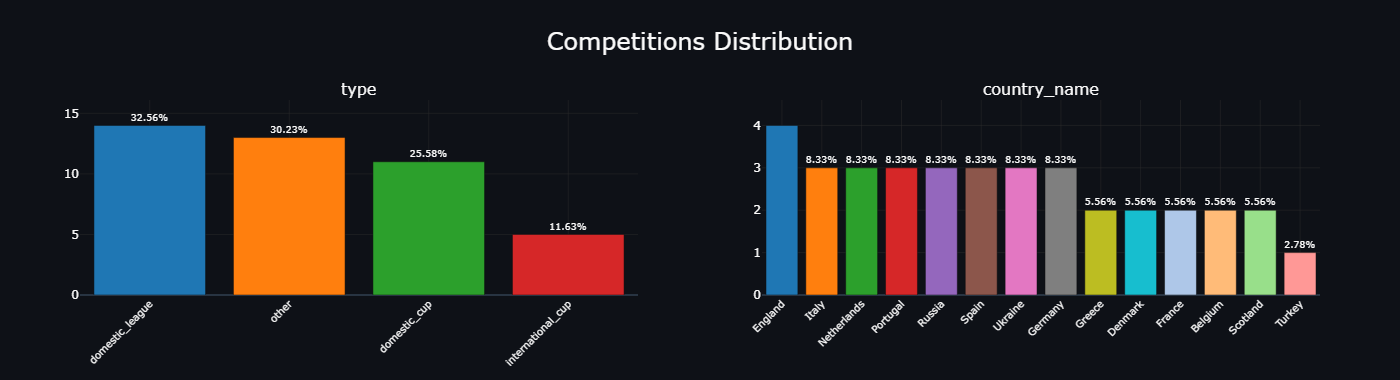

In [7]:
id_cols = ["competition_id", 'name']

competitions_dist = distribution_plot(competitions_summary, n_cols=2, title='Competitions Distribution',top_n_categories=20, ignore_cols=id_cols)
competitions_dist

<div class="alert alert-block alert-success">

### **Competitions summary:** 
this table stores the data of each football competition

### **columns:**
**competition_id:** unique string id of the competition

**name:** full name of the competition

**type:** type of the competition , we have only 4 types(domestic, international , ...)

**country_name:** name of the country where competition belongs to.(it has 7 null values for competitions that are international)

### **no opportunity for cleaning/transforming**

<div class="alert alert-block alert-success">

## **Table: Clubs**

In [8]:
clubs_summary = run_query('select * from clubs')
clubs_summary.head(10)

,club_id,name,domestic_competition_id,squad_size,foreigners_number,national_team_players,stadium_name,stadium_seats,net_transfer_record
0,2578,Saint Johnstone Football Club,SC1,25,16,2,McDiarmid Park,10696,+-0
1,2727,Oud-Heverlee Leuven,BE1,29,16,2,King Power at Den Dreef Stadion,10020,+300k
2,28643,SK Beveren,BE1,27,16,3,Freethielstadion,13290,-350k
3,2990,Académica Coimbra,PO1,26,6,0,Estádio Cidade de Coimbra,29744,+150k
4,3057,Royal Standard Club de Liège,BE1,27,18,10,Maurice Dufrasne Stadion,27670,+3.11m
5,3690,SKA Khabarovsk,RU1,27,4,0,Lenin Stadion,15200,-93k
6,4795,FC Ingolstadt 04,L1,28,8,1,Audi Sportpark,15800,+1.55m
7,511,Dundee Football Club,SC1,26,16,3,Kilmac Stadium at Dens Park,11850,+-0
8,5358,SD Huesca,ES1,24,8,2,El Alcoraz,9128,+1.43m
9,603,Cardiff City,GB1,28,24,8,Cardiff City Stadium,33280,-655k


In [9]:
clubs_summary.describe()

,club_id,squad_size,foreigners_number,national_team_players,stadium_seats
count,426.000000,426.000000,426.000000,426.000000,426.000000
mean,5314.525822,24.288732,10.992958,4.866197,24299.420188
std,11752.013818,8.735255,6.617798,4.982646,17192.103990
min,3.000000,0.000000,0.000000,0.000000,1312.000000
25%,421.000000,24.000000,6.000000,1.000000,11024.500000
50%,1139.500000,27.000000,12.000000,3.000000,20046.000000
75%,3415.750000,29.000000,16.000000,8.000000,32448.000000
max,83678.000000,41.000000,26.000000,21.000000,81365.000000


In [10]:
clubs_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   club_id                  426 non-null    int64
 1   name                     426 non-null    str  
 2   domestic_competition_id  426 non-null    str  
 3   squad_size               426 non-null    int64
 4   foreigners_number        426 non-null    int64
 5   national_team_players    426 non-null    int64
 6   stadium_name             426 non-null    str  
 7   stadium_seats            426 non-null    int64
 8   net_transfer_record      426 non-null    str  
dtypes: int64(5), str(4)
memory usage: 49.9 KB


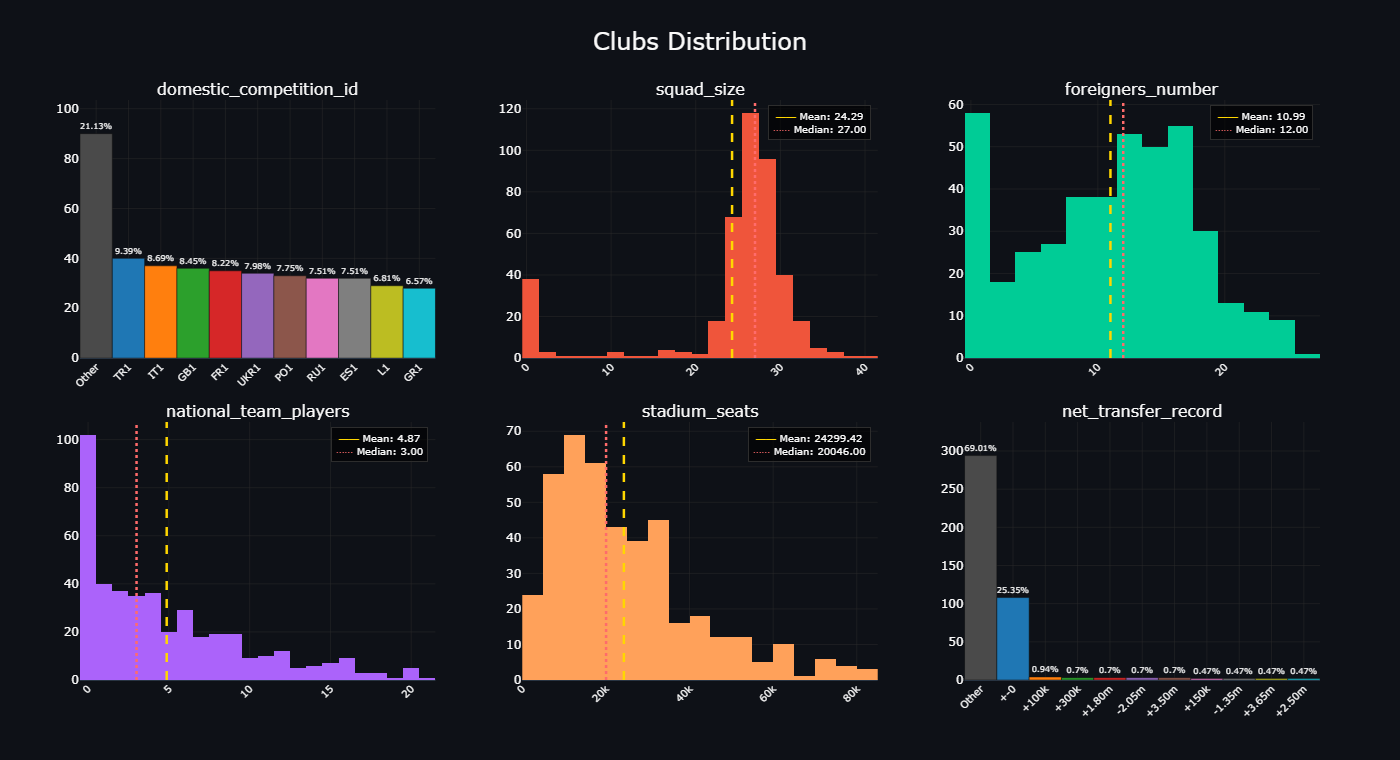

In [11]:
ignore_list = ['name', 'club_id', 'stadium_name']
clubs_dist = distribution_plot(clubs_summary, title="Clubs Distribution", n_cols=3, ignore_cols=ignore_list)
clubs_dist

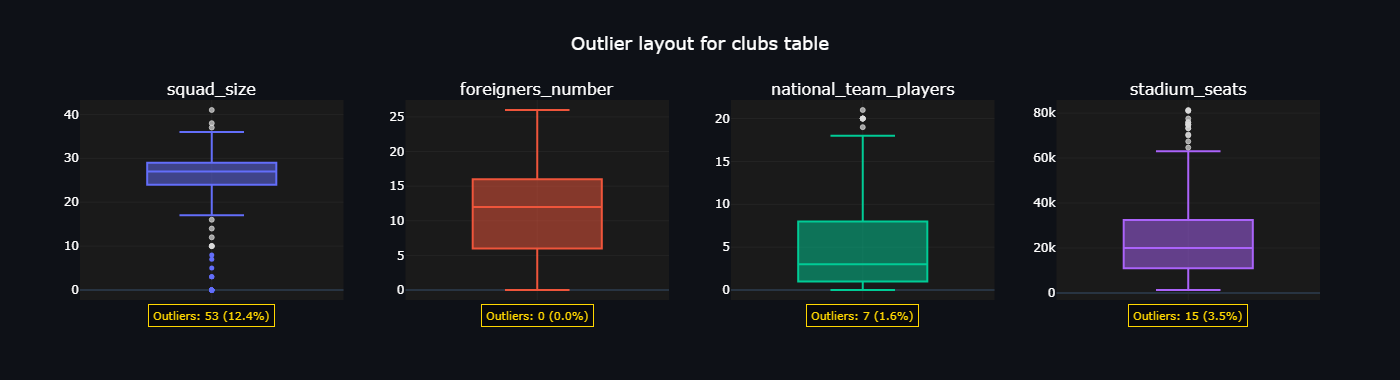

In [12]:
clubs_boxplot = outlier_plot(df=clubs_summary, ignore_list=ignore_list, title="Outlier layout for clubs table", orientation='vertical', n_cols=4)
clubs_boxplot

<div class="alert alert-block alert-success">

### **clubs summary:** 
this table stores the data of each football club

### **columns:**
**club_id:** unique id of each football club

**name:** full name of the football club

**domestic_competition_id:** the domestic competition id of the club 

**squad_size:** size of the whole football team (this column has the most outliers)

**foreigners_number:** number of foreign people in the team

**national_team_players:** number of players that are in the international team of their own country

**stadium_name:** name of the owned stadium of the club 

**stadium_seats:** number of seats in the club's stadium 

**net_transfer_record:** net value of the club

### **opportunity for cleaning/transforming:**
- transform the net_transfer_record column to show the pure number without any + ,- ,k or m symbol 

<div class="alert alert-block alert-success">

## **Table: Players**

In [13]:
players_summary = run_query('select * from players')
players_summary.head(10)

,player_id,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date
0,569140,290,lassine-sinayoko,NaN,Bamako,NaN,1999-12-08,Right Winger,Attack,right,186.0,2025-06-30
1,569368,44,kelian-nsona,NaN,Ivry-sur-Seine,NaN,2002-05-11,Right Winger,Attack,right,189.0,2026-06-30
2,569385,1158,adil-aouchiche,NaN,Le Blanc-Mesnil,NaN,2002-07-15,Attacking Midfield,Midfield,right,181.0,2026-06-30
3,607809,11127,ilya-bykovskiy,NaN,"Lyubertsy, Moskau Oblast",NaN,2001-02-16,Left-Back,Defender,left,177.0,2024-06-30
4,627221,720,gabriel-veron,NaN,Assu,NaN,2002-09-03,Right Winger,Attack,right,176.0,2027-06-30
5,627294,1050,fer-nino,NaN,Rota,NaN,2000-10-24,Centre-Forward,Attack,right,191.0,2026-06-30
6,650519,2424,lucas-barros,NaN,Rio de Janeiro,NaN,1999-08-21,Left-Back,Defender,left,180.0,2024-06-30
7,655835,989,christian-saydee,NaN,London,NaN,2002-05-10,Centre-Forward,Attack,right,184.0,2026-06-30
8,668184,150,quique-fernandez,NaN,Trebujena,NaN,2003-09-16,Defensive Midfield,Midfield,left,177.0,2024-06-30
9,669312,83678,yevgeniy-ryazantsev,NaN,Kyiv,NaN,2002-01-28,Right Winger,Attack,right,186.0,2024-06-30


In [14]:
players_summary.describe()

,player_id,current_club_id,height_in_cm
count,1.536000e+04,15360.000000,14363.000000
mean,4.372485e+05,5195.039258,182.625009
std,2.680993e+05,12220.348699,7.162323
min,2.857000e+03,3.000000,18.000000
25%,2.139785e+05,385.000000,178.000000
50%,4.101985e+05,1041.000000,183.000000
75%,6.284945e+05,3060.000000,188.000000
max,1.240762e+06,83678.000000,206.000000


In [15]:
players_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 15360 entries, 0 to 15359
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 15360 non-null  int64  
 1   current_club_id           15360 non-null  int64  
 2   player_code               15360 non-null  str    
 3   country_of_birth          13598 non-null  str    
 4   city_of_birth             14113 non-null  str    
 5   country_of_citizenship    14782 non-null  str    
 6   date_of_birth             15354 non-null  object 
 7   sub_position              15329 non-null  str    
 8   position                  15329 non-null  str    
 9   foot                      14384 non-null  str    
 10  height_in_cm              14363 non-null  float64
 11  contract_expiration_date  12928 non-null  object 
dtypes: float64(1), int64(2), object(2), str(7)
memory usage: 2.3+ MB


In [16]:
# we have some missing data which is ok

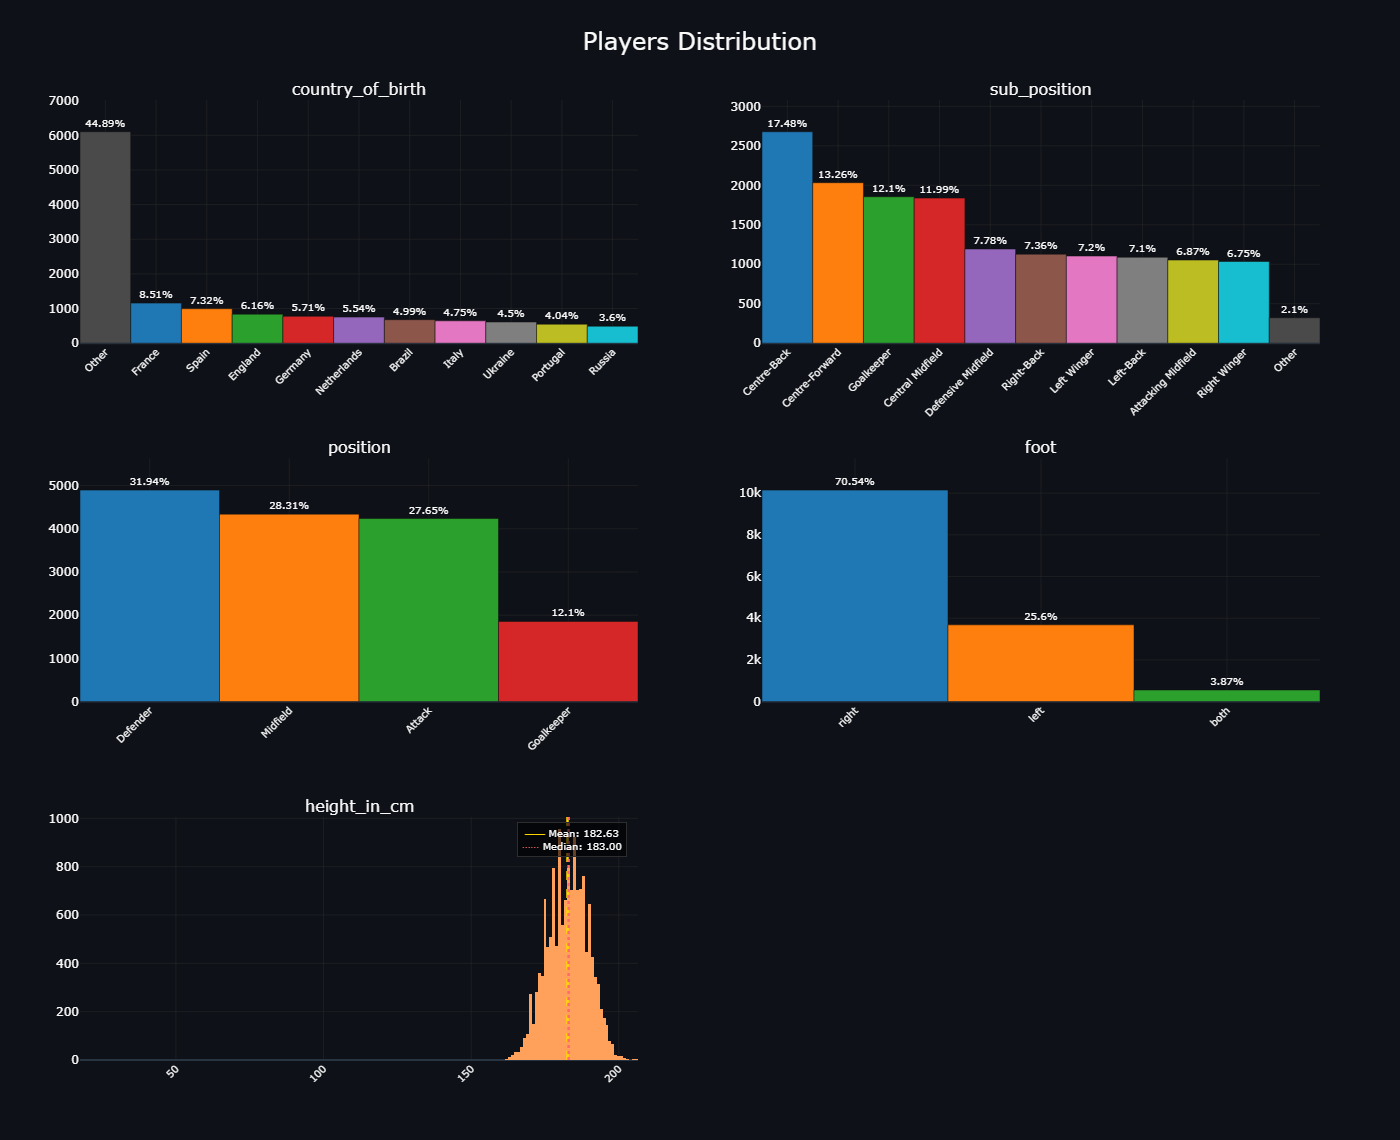

In [17]:
ignore_list=['player_id', 'current_club_id', 'country_of_citizenship', 'city_of_birth', 'contract_expiration_date', 'player_code', 'date_of_birth']
players_dist = distribution_plot(players_summary, ignore_cols=ignore_list,title='Players Distribution', n_cols=2)
players_dist.show(renderer='png')

In [ ]:
# height distribution is highly skewed because of two players with 18 cm of height
players_summary[players_summary['height_in_cm'].between(15, 20)]

# these are real players but they are definitely not 18 centimeters , i will include this in the cleaning to replace these heights with median

,player_id,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date
11525,592398,40,aissa-boudechicha,NaN,Medjana,Algeria,2000-04-13,Left-Back,Defender,left,18.0,2023-06-30
12206,628490,2687,genar-fornes,Spain,Barcelona,Spain,2000-01-17,Left-Back,Defender,left,18.0,2023-06-30


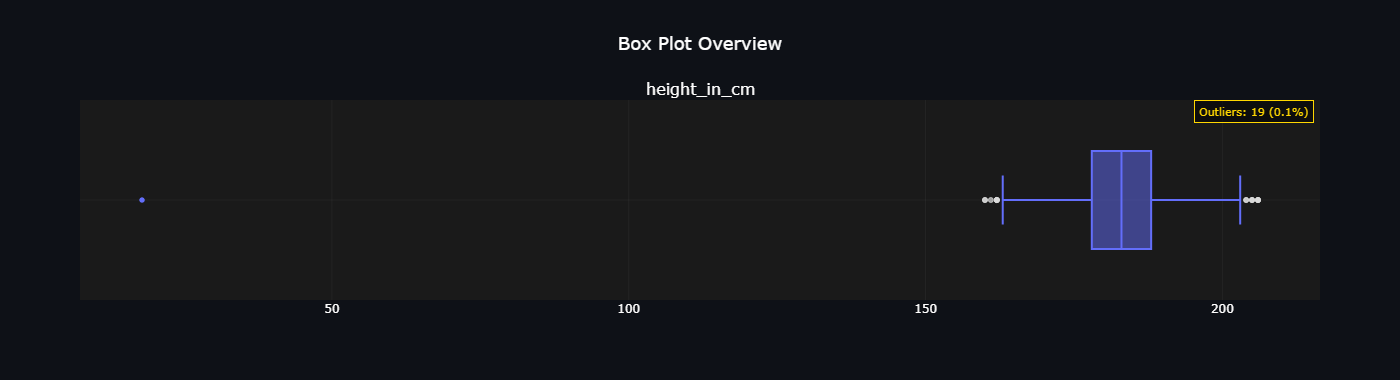

In [19]:
players_boxplot = outlier_plot(players_summary, ignore_list=ignore_list, orientation='horizonatal', n_cols=1)
players_boxplot.show(renderer='png')
# we can see the same outlier in heights

<div class="alert alert-block alert-success">

### **players summary:**
this table stores the data of football players

### **columns:**

**player_id:** unique id of each football player

**current_club_id:** current club id of the player 

**player_code:** full name of the player seperated with -  

**position:** main position of the player in the field

**foot:** dominant foot of the player (left, right, both)

**other columns that don't need explanation:** country_of_birth, city_of_birth, country_of_citizenship, date_of_birth, sub_position, height_in_cm, contract_expiration_date 

### **opportunity for cleaning/transforming:**
- splitting player_code to first_name and last_name
- replacing the players height_in_cm lower then 100cm with the median or mean 

<div class="alert alert-block alert-success">

## **Table: Games**

In [20]:
games_summary = run_query('select * from games')
games_summary.head(10)

,game_id,competition_id,season,date,home_club_id,away_club_id,home_club_goals,away_club_goals,stadium,attendance
0,3394572,FR1,2020,2020-08-30,1421,1082,0,1,Stade Auguste-Delaune,3614.0
1,3406929,RU1,2020,2020-08-15,2698,11127,1,1,Ak Bars Arena,4088.0
2,3409238,RU1,2020,2020-08-22,964,41201,4,1,Gazprom Arena,20782.0
3,3409250,RU1,2020,2020-08-26,121,964,1,0,VTB-Arena,5885.0
4,3409253,RU1,2020,2020-08-29,3719,3609,1,1,Arena Khimki,2541.0
5,3412888,L1,2020,2020-09-19,89,167,1,3,Stadion An der Alten Försterei,4500.0
6,3415298,BE1,2020,2020-09-27,58,1245,1,1,Lotto Park,6000.0
7,3415310,BE1,2020,2020-10-17,520,157,5,2,Jan-Breydel-Stadion,2500.0
8,3421818,GB1,2020,2020-12-27,31,984,1,1,Anfield,2000.0
9,3429855,GB1,2020,2021-05-18,631,1003,2,1,Stamford Bridge,7195.0


In [21]:
games_summary.describe()

,game_id,season,home_club_id,away_club_id,home_club_goals,away_club_goals,attendance
count,1.798100e+04,17981.000000,17981.000000,17981.000000,17981.000000,17981.000000,12987.000000
mean,3.761244e+06,2021.487292,3919.367555,3911.942439,1.560647,1.286191,20495.174405
std,2.639090e+05,1.113482,10116.851533,10113.551524,1.352522,1.235264,18902.657029
min,3.393086e+06,2020.000000,3.000000,3.000000,0.000000,0.000000,23.000000
25%,3.537804e+06,2020.000000,331.000000,331.000000,1.000000,0.000000,5659.500000
50%,3.763705e+06,2021.000000,873.000000,873.000000,1.000000,1.000000,14271.000000
75%,4.056038e+06,2022.000000,2671.000000,2671.000000,2.000000,2.000000,30210.000000
max,4.340617e+06,2023.000000,83678.000000,83678.000000,12.000000,13.000000,95745.000000


In [22]:
games_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_id          17981 non-null  int64  
 1   competition_id   17981 non-null  str    
 2   season           17981 non-null  int64  
 3   date             17981 non-null  object 
 4   home_club_id     17981 non-null  int64  
 5   away_club_id     17981 non-null  int64  
 6   home_club_goals  17981 non-null  int64  
 7   away_club_goals  17981 non-null  int64  
 8   stadium          17981 non-null  str    
 9   attendance       12987 non-null  float64
dtypes: float64(1), int64(6), object(1), str(2)
memory usage: 1.7+ MB


In [23]:
# we have null values only attendance column which is not too much and its ok

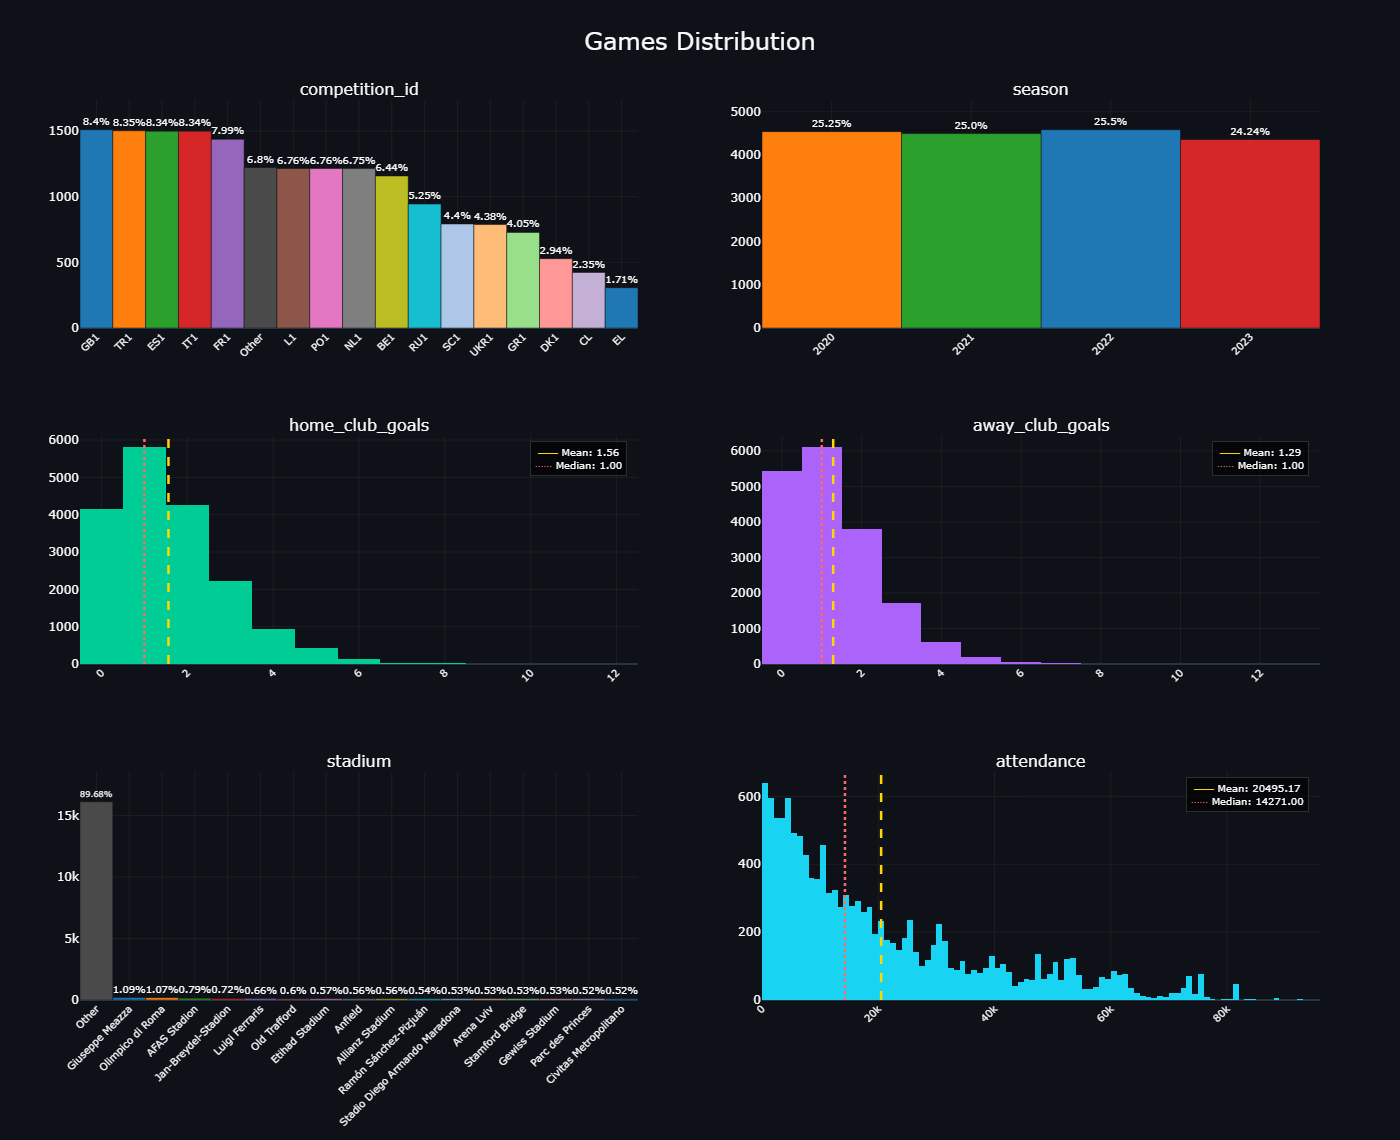

In [24]:
ignore_list = ['game_id', 'date', 'home_club_id', 'away_club_id']
games_dist = distribution_plot(games_summary, title='Games Distribution', ignore_cols=ignore_list, top_n_categories=16)
games_dist.show(renderer='png')

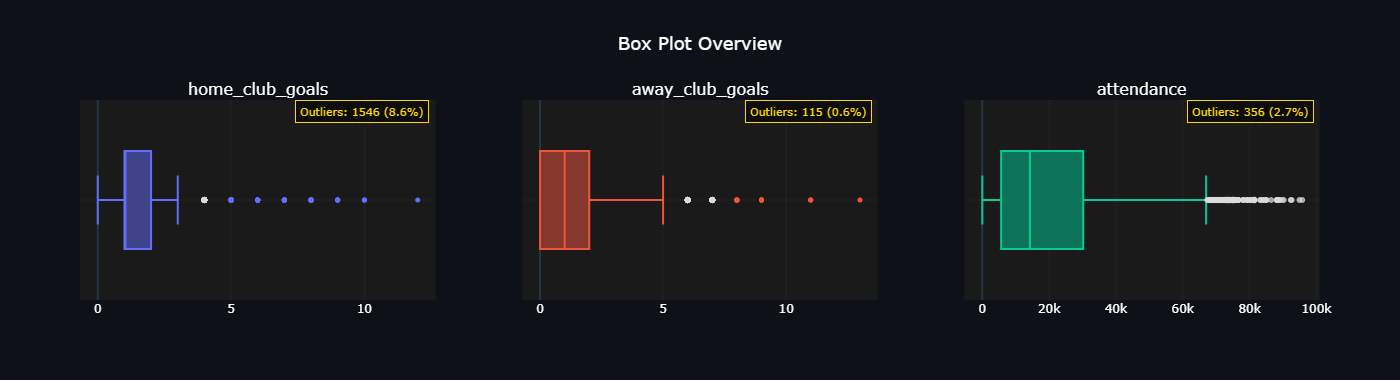

In [25]:
ignore_list = ['game_id', 'home_club_id', 'away_club_id', 'season']
games_boxplot = outlier_plot(games_summary ,orientation='horizontal', ignore_list=ignore_list, n_cols=3)
games_boxplot.show(renderer='png')

<div class="alert alert-block alert-success">

### **Games summary:**
this table stores the data of each football game 

### **columns:**

**game_id:** unique id of the football match

**competition_id:** string id of the game's competition class  

**season:** the year that match took place  

**home_club_id:** id of the hosting team

**away_club_id:** away from home team id 

**stadium:** name of the stadium that match took place

**attendance:** number of attendees in the stadium 

**other columns that don't need explanation:** date, home_club_goals, away_club_goals 

### **no opportunity for cleaning/transforming**
 

<div class="alert alert-block alert-success">

## **Table: appearances**

In [26]:
appearances_summary = run_query('select * from appearances')
appearances_summary.head(10)

,appearance_id,game_id,player_id,yellow_cards,red_cards,goals,assists,minutes_played
0,3393960_546880,3393960,546880,0,0,0,0,48
1,3393960_57370,3393960,57370,0,0,1,0,90
2,3393960_640428,3393960,640428,0,0,0,1,26
3,3393960_73734,3393960,73734,0,0,0,0,90
4,3393960_84301,3393960,84301,0,0,0,0,90
5,3393964_137841,3393964,137841,0,0,0,0,45
6,3393964_154199,3393964,154199,0,0,0,0,90
7,3393964_163568,3393964,163568,0,0,0,0,90
8,3393964_18934,3393964,18934,0,0,0,0,76
9,3393964_210081,3393964,210081,0,0,0,0,90


In [27]:
appearances_summary.describe()

,game_id,player_id,yellow_cards,red_cards,goals,assists,minutes_played
count,5.232380e+05,5.232380e+05,523238.000000,523238.000000,523238.000000,523238.000000,523238.000000
mean,3.762633e+06,3.166417e+05,0.139575,0.003736,0.090036,0.069743,65.637660
std,2.636542e+05,2.016094e+05,0.356120,0.061011,0.318326,0.273534,31.085752
min,3.393086e+06,3.333000e+03,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3.534564e+06,1.591420e+05,0.000000,0.000000,0.000000,0.000000,45.000000
50%,3.828504e+06,2.897130e+05,0.000000,0.000000,0.000000,0.000000,84.000000
75%,4.056162e+06,4.412870e+05,0.000000,0.000000,0.000000,0.000000,90.000000
max,4.340617e+06,1.240467e+06,2.000000,1.000000,5.000000,4.000000,120.000000


In [28]:
appearances_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 523238 entries, 0 to 523237
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   appearance_id   523238 non-null  str  
 1   game_id         523238 non-null  int64
 2   player_id       523238 non-null  int64
 3   yellow_cards    523238 non-null  int64
 4   red_cards       523238 non-null  int64
 5   goals           523238 non-null  int64
 6   assists         523238 non-null  int64
 7   minutes_played  523238 non-null  int64
dtypes: int64(7), str(1)
memory usage: 38.8 MB


In [29]:
# no missing data :)

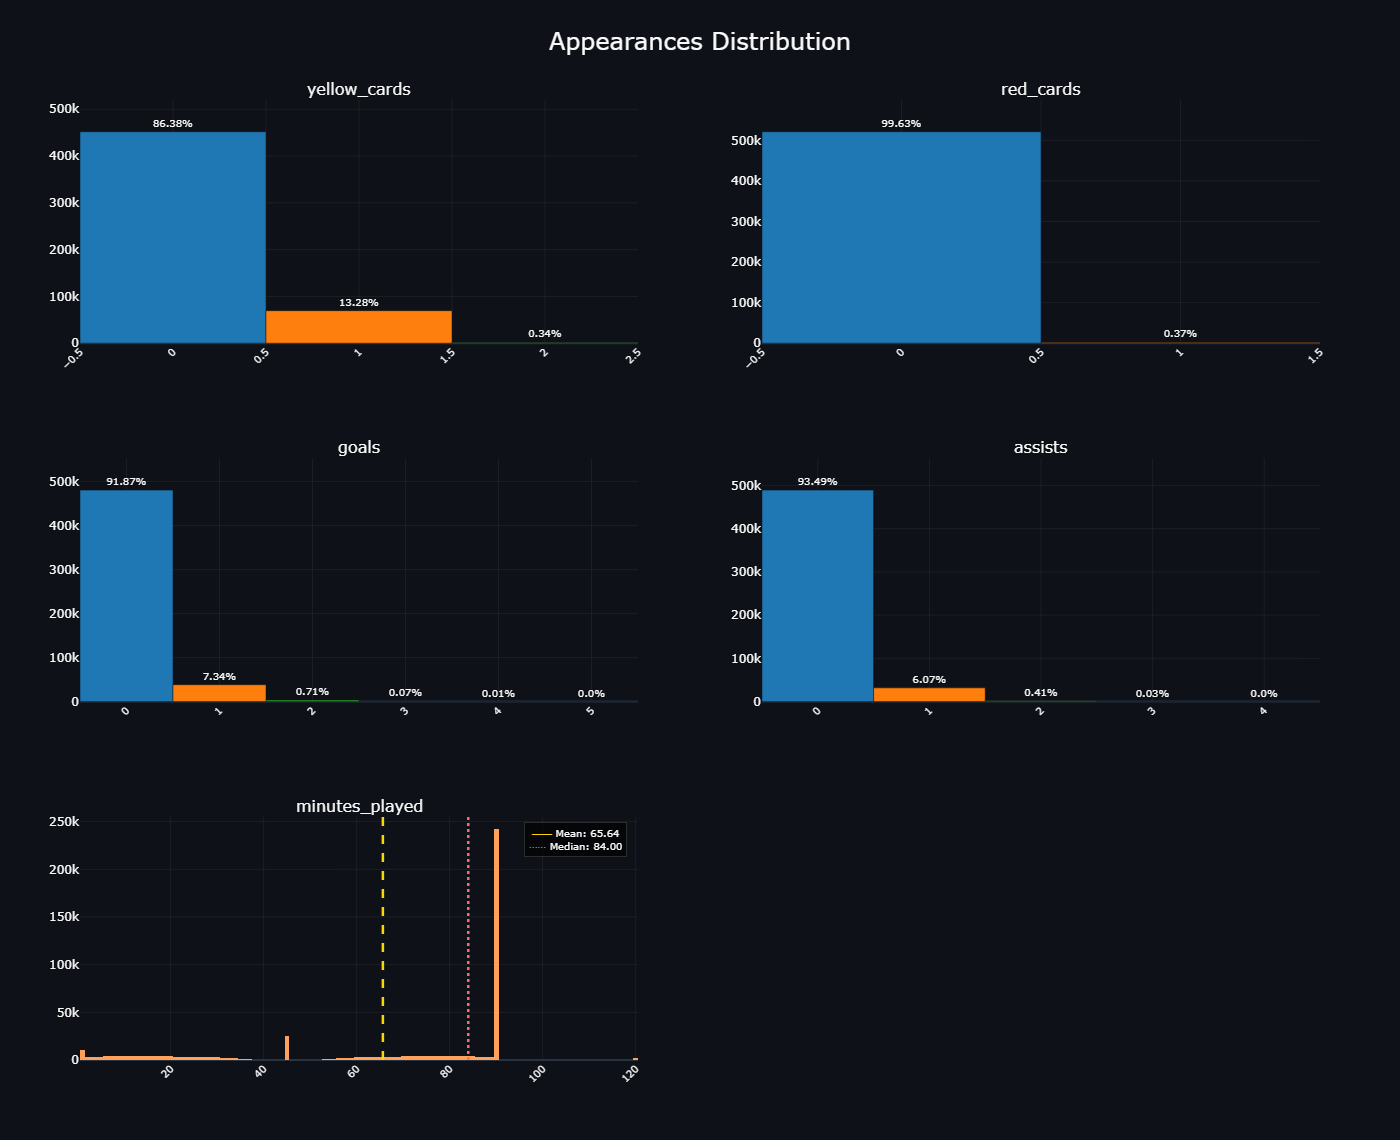

In [30]:
ignore_list = ['appearance_id', 'game_id', 'player_id']
appearances_dist = distribution_plot(appearances_summary, ignore_cols=ignore_list, title='Appearances Distribution',n_cols=2)
appearances_dist.show(renderer="png")

In [31]:
# appearances outlier plot is too heavy and slowes down scrolling so we will just skip it because its not important in this table

<div class="alert alert-block alert-success">

### **Appearances summary:**
this table stores the detailed data of player appearances in football games

### **columns:**

**appearance_id:** composite key of game_id and player_id which identifies each appearances of different players in different games uniquely 

**yellow_card:** number of yellow cards player received in this appearance   

**red_cards:** player received red card or not in this appearance(1 or 0)

**goals:** number of goals player scored in the game

**assists:** number of assists from the player in the game 

**minutes_played:** the amount of time player was in the field in minutes(bi-modal ditribution spiking at 46 and 90)

**other columns that don't need explanation:** game_id, player_id

### **no opportunity for cleaning/transforming**
 

<div class="alert alert-block alert-success">

## **Table: game_events**

In [32]:
game_events_summary = run_query('select * from game_events')
game_events_summary

,game_event_id,game_id,minute,type,player_id,player_in_id,player_assist_id
0,8136215,3394570,87,Substitutions,640428,463613.0,NaN
1,3642565,3394571,72,Substitutions,68864,332889.0,NaN
2,4186651,3394571,79,Substitutions,92693,60540.0,NaN
3,7478774,3394571,85,Substitutions,138055,474662.0,NaN
4,7776756,3394571,79,Substitutions,174094,485963.0,NaN
...,...,...,...,...,...,...,...
215949,8354873,4098117,61,Goals,23553,NaN,41583.0
215950,9754961,4098117,90,Goals,465326,NaN,582131.0
215951,3196454,4098118,58,Goals,147034,NaN,256718.0
215952,6636404,4098118,8,Goals,308265,NaN,436064.0


In [33]:
game_events_summary.describe()

,game_event_id,game_id,minute,player_id,player_in_id,player_assist_id
count,2.159540e+05,2.159540e+05,215954.000000,2.159540e+05,1.469850e+05,9.463000e+03
mean,5.507755e+06,3.800054e+06,64.833529,3.252698e+05,3.597930e+05,3.830587e+05
std,2.599034e+06,2.710951e+05,21.016721,1.997808e+05,2.207021e+05,2.144306e+05
min,1.000002e+06,3.393086e+06,-1.000000,3.333000e+03,3.333000e+03,3.333000e+03
25%,3.265605e+06,3.589098e+06,55.000000,1.709610e+05,1.844730e+05,2.170330e+05
50%,5.509239e+06,3.840112e+06,69.000000,3.023710e+05,3.388170e+05,3.579170e+05
75%,7.757021e+06,4.096024e+06,81.000000,4.491510e+05,5.083710e+05,5.324440e+05
max,9.999990e+06,4.340617e+06,120.000000,1.229924e+06,1.240467e+06,1.166093e+06


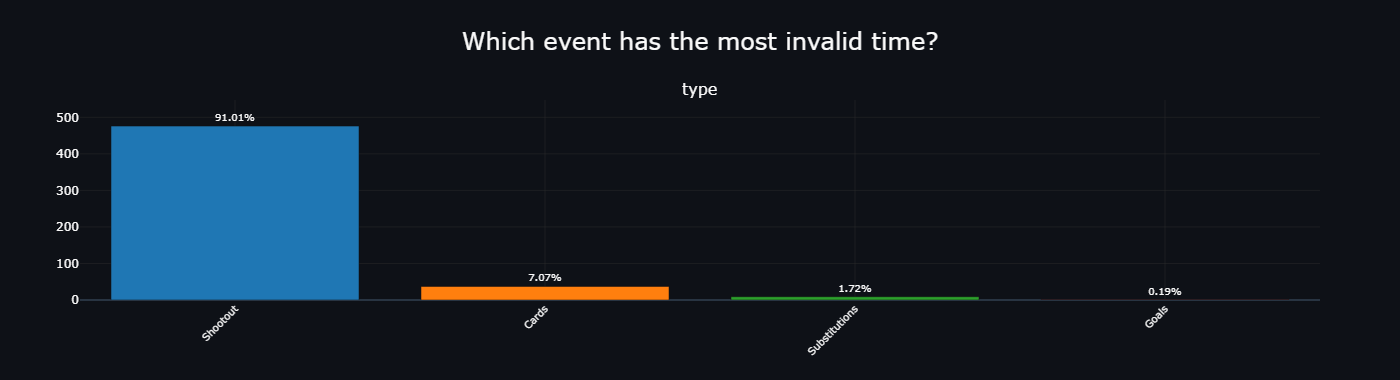

In [34]:
# we have minutes lower than 1?
invalid_time_df = game_events_summary[game_events_summary['minute'] < 1]
invalid_time_dist = distribution_plot(invalid_time_df[['type']], n_cols=1, title='Which event has the most invalid time?')
invalid_time_dist.show(renderer="png")


In [35]:
# seems like shootout events time wasn't recorder properly and they just submitted it as -1

In [36]:
game_events_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 215954 entries, 0 to 215953
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   game_event_id     215954 non-null  int64  
 1   game_id           215954 non-null  int64  
 2   minute            215954 non-null  int64  
 3   type              215954 non-null  str    
 4   player_id         215954 non-null  int64  
 5   player_in_id      146985 non-null  float64
 6   player_assist_id  9463 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 13.7 MB


In [37]:
# the null values of player_in_id is because the event type was not 'Substitutions'
# the null values of player_assist_id is because the event type was not 'Goals'

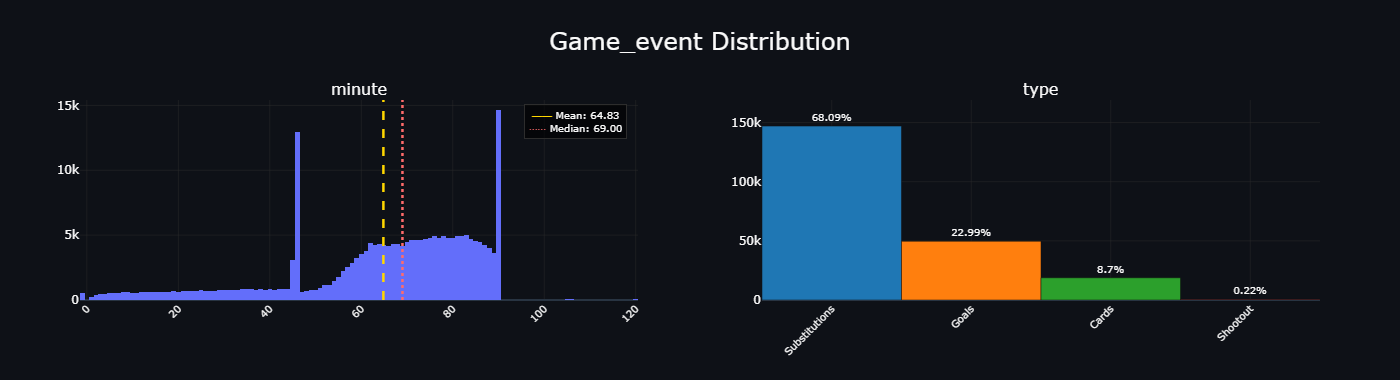

In [38]:
ignore_list = ['game_event_id', 'game_id', 'player_id', 'player_in_id', 'player_assist_id']
game_events_dist = distribution_plot(game_events_summary, title='Game_event Distribution', ignore_cols=ignore_list, n_cols=2)
game_events_dist.show(renderer="png")

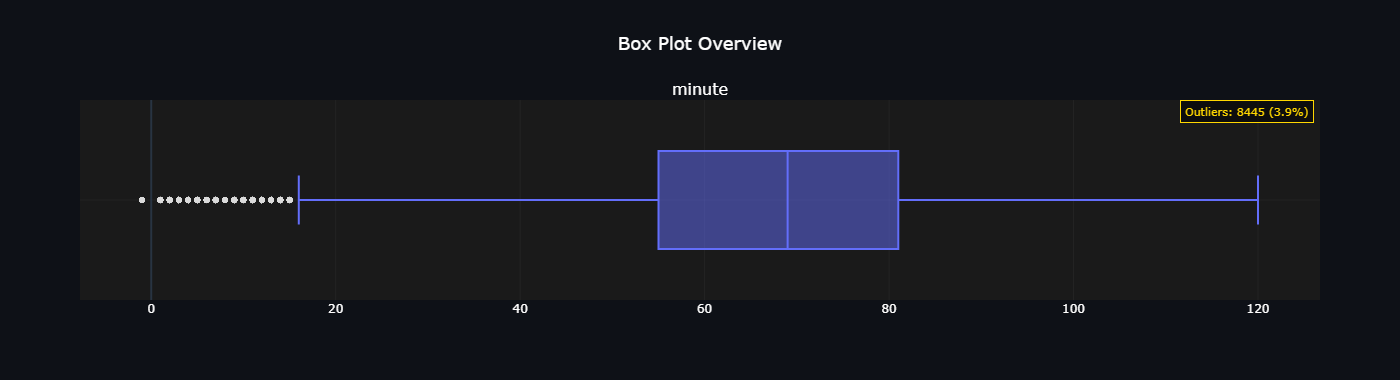

In [39]:
ignore_list = ['game_event_id', 'game_id', 'player_id', 'player_in_id', 'player_assist_id']

game_events_boxplot = outlier_plot(game_events_summary, ignore_list=ignore_list, n_cols=1)
game_events_boxplot.show(renderer="png")

<div class="alert alert-block alert-success">

### **Games_event summary:**
this table stores the detailed data of different events in the match

### **columns:**

**game_event_id:** unique id of different events in different games

**game_id:** id of the game that event took place

**minute:** time of the event occurred in the game(its a bi-modal distibution spiking at 46 and 90)

**type:** type of the event(shootout, substitutions, goals, cards)

**player_id:** id of the player who scored the goal or got substituted out, or received the card, or shootout 

**player_in_id:** id of the player who got in the field in substitution (logically this column is missing in other event types other than 'substitutions')

**player_assist_id:** id of the player who gave the assist to score the goal (logically this column is missing in other event types other than 'goals')

### **opportunity for cleaning/transforming:**
- handling the '-1' minute but the best approach is to live it at -1 because 90 percent of the '-1' minute columns are shootout events and replacing them with median or mean will cause biased analysis on shootout events
 